# Binary One vs All XGBoost

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score, label_ranking_average_precision_score
import joblib
from tqdm import tqdm
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold, MultilabelStratifiedShuffleSplit
import os
from utils import optimize_thresholds_multivariate, evaluate_optimized

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


**final_features.csv combined train_audio and soundscape with 84 features**

In [2]:
df = pd.read_csv("../../output/final_features.csv")
df['final_labels'] = df['final_labels'].apply(lambda x: x.split() if isinstance(x, str) else [])

In [3]:
mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(df['final_labels'])
X = df.filter(regex='mean|std') 

print(f"Classes trouvées : {len(mlb.classes_)}")

Classes trouvées : 234


In [4]:
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

msss_1 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(msss_1.split(X, Y))

X_train, X_temp = X.iloc[train_idx], X.iloc[temp_idx]
y_train, y_temp = Y[train_idx], Y[temp_idx]

msss_2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
val_idx, test_idx = next(msss_2.split(X_temp, y_temp))

X_val, X_test = X_temp.iloc[val_idx], X_temp.iloc[test_idx]
y_val, y_test = y_temp[val_idx], y_temp[test_idx]

print(f"--- Répartition des données ---")
print(f"Train : {len(X_train)} samples")
print(f"Val   : {len(X_val)} samples")
print(f"Test  : {len(X_test)} samples")

--- Répartition des données ---
Train : 135049 samples
Val   : 46332 samples
Test  : 11495 samples


## Baseline (with out pos_weight)

In [ ]:
print("\nEntraînement du modèle unique")
models = []
for i in tqdm(range(y_train.shape[1]), desc="Training labels"):
    model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        tree_method='hist',
        objective='binary:logistic',
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train[:, i])
    models.append(model)
    
def evaluate(X_set, y_true, set_name="Validation"):
    preds_proba_list = [model.predict_proba(X_set) for model in models]
    preds_proba = np.transpose([p[:, 1] for p in preds_proba_list])
    preds_bin = (preds_proba > 0.3).astype(int)
    
    f1 = f1_score(y_true, preds_bin, average='macro', zero_division=0)
    lrap = label_ranking_average_precision_score(y_true, preds_proba)
    
    print(f"\nRésultats sur {set_name} :")
    print(f"Macro F1 : {f1:.4f}")
    print(f"LRAP     : {lrap:.4f}")
    return f1

evaluate(X_val, y_val, "Validation")
evaluate(X_test, y_test, "Test (Final)")



Entraînement du modèle unique...


Training labels: 100%|██████████| 234/234 [05:17<00:00,  1.36s/it]



Résultats sur Validation :
Macro F1 : 0.4726
LRAP     : 0.5922

Résultats sur Test (Final) :
Macro F1 : 0.4800
LRAP     : 0.5942


FileNotFoundError: [Errno 2] No such file or directory: 'models/xgb_single_model.pkl'

In [ ]:

joblib.dump(models, "../../output/xgb_single_model.pkl")
joblib.dump(mlb, "../../output/mlb.pkl")

['../../output/mlb.pkl']

## with pos weight and 500 iterations

In [ ]:
print("\nTraining with Dynamic Class Imbalance Correction")
models = []

for i in tqdm(range(y_train.shape[1]), desc="Training labels"):
    pos_count = np.sum(y_train[:, i] == 1)
    neg_count = np.sum(y_train[:, i] == 0)
    
    if pos_count > 0:
        spw = neg_count / pos_count
        spw = min(spw, 100)
    else:
        spw = 1

    model = xgb.XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.1,
        tree_method='hist',
        objective='binary:logistic',
        scale_pos_weight=spw,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train[:, i])
    models.append(model)

def evaluate(X_set, y_true, set_name="Validation"):
    preds_proba_list = [model.predict_proba(X_set)[:, 1] for model in models]
    preds_proba = np.column_stack(preds_proba_list)

    preds_bin = (preds_proba > 0.3).astype(int)
    
    f1 = f1_score(y_true, preds_bin, average='macro', zero_division=0)
    lrap = label_ranking_average_precision_score(y_true, preds_proba)
    
    print(f"\nResults on {set_name}:")
    print(f"Macro F1 : {f1:.4f}")
    print(f"LRAP     : {lrap:.4f}")
    return f1

evaluate(X_val, y_val, "Validation")
evaluate(X_test, y_test, "Test (Final)")


Training with Dynamic Class Imbalance Correction...


Training labels: 100%|██████████| 234/234 [13:44<00:00,  3.52s/it]



Results on Validation:
Macro F1 : 0.6050
LRAP     : 0.6252

Results on Test (Final):
Macro F1 : 0.5993
LRAP     : 0.6267


0.5992818021587297

## Pos weight + variation of threshold per class

In [16]:
print("\nTraining with Dynamic Class Imbalance Correction")
models = []

for i in tqdm(range(y_train.shape[1]), desc="Training labels"):
    pos_count = np.sum(y_train[:, i] == 1)
    neg_count = np.sum(y_train[:, i] == 0)
    
    if pos_count > 0:
        spw = neg_count / pos_count
        spw = min(spw, 100)
    else:
        spw = 1

    model = xgb.XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.1,
        tree_method='hist',
        objective='binary:logistic',
        scale_pos_weight=spw,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train[:, i])
    models.append(model)



Training with Dynamic Class Imbalance Correction


Training labels: 100%|██████████| 234/234 [15:51<00:00,  4.06s/it]


In [17]:
print("Optimizing thresholds on Validation Set")
val_probs, _ = evaluate_optimized(X_val, y_val, thresholds=None, set_name="Validation", models=models)
opt_thresholds = optimize_thresholds_multivariate(y_val, val_probs)

evaluate_optimized(X_val, y_val, thresholds=opt_thresholds, set_name="Validation", models=models)

evaluate_optimized(X_test, y_test, thresholds=opt_thresholds, set_name="Test (Final)", models=models)

Optimizing thresholds on Validation Set

Results on Validation (Static (0.3)):
Macro F1 : 0.6050
LRAP     : 0.6252
Starting Multivariate Optimization (3 epochs)...


Epoch 3/3: 100%|██████████| 234/234 [25:38<00:00,  6.57s/it]



Results on Validation (Optimized):
Macro F1 : 0.6479
LRAP     : 0.6252

Results on Test (Final) (Optimized):
Macro F1 : 0.6260
LRAP     : 0.6267


(array([[6.2071331e-06, 1.0319606e-06, 6.5411587e-07, ..., 8.1756501e-04,
         6.3454463e-06, 8.6793712e-05],
        [9.9958020e-01, 2.3459627e-06, 2.4294689e-06, ..., 1.7356342e-03,
         3.1568140e-06, 1.3640723e-02],
        [9.9967515e-01, 7.6182887e-06, 3.9154556e-06, ..., 1.1447318e-05,
         1.2905014e-07, 1.4657908e-04],
        ...,
        [5.4818092e-06, 1.4407579e-04, 1.0199476e-06, ..., 8.4578705e-06,
         3.0046338e-05, 9.6550946e-05],
        [4.1539263e-07, 1.1316814e-06, 1.3466874e-06, ..., 1.5003872e-01,
         2.2940668e-07, 1.4732420e-02],
        [1.8270715e-06, 6.7498848e-07, 1.3439009e-06, ..., 1.4400698e-01,
         1.1821886e-06, 3.6202282e-02]], shape=(11495, 234), dtype=float32),
 0.6259897878054814)

## Hyperparameter Tuning

Tuning Learning Rates: 100%|██████████| 4/4 [00:17<00:00,  4.27s/it]


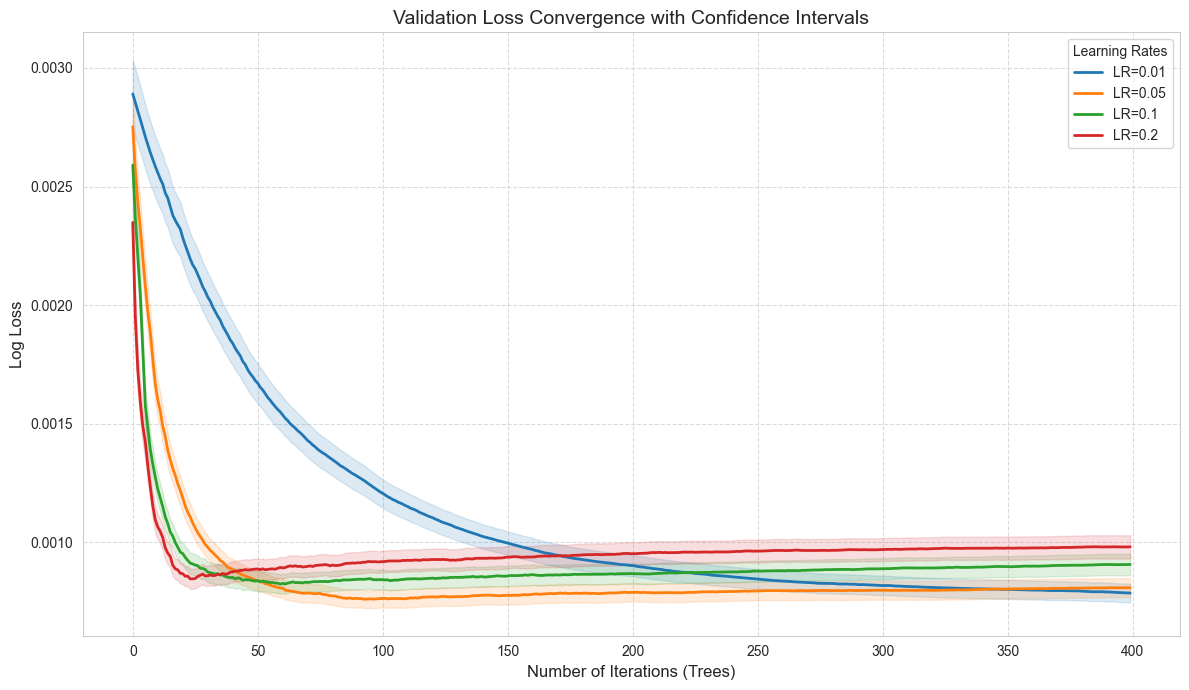

In [12]:
from tqdm import tqdm
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

def learning_rate_tuning(X_tr, y_tr, X_v, y_v):
    target_col = 0
    learning_rates = [0.01, 0.05, 0.1, 0.2]
    results = []

    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid") 
    for lr in tqdm(learning_rates, desc="Tuning Learning Rates"):
        model = xgb.XGBClassifier(
            n_estimators=400,
            max_depth=6,
            learning_rate=lr,
            objective='binary:logistic',
            tree_method='hist',
            eval_metric=['logloss', 'auc'],
            random_state=42
        )
        
        model.fit(
            X_tr, y_tr[:, target_col], 
            eval_set=[(X_v, y_v[:, target_col])], # Track validation loss
            verbose=False
        )
        
        evals_result = model.evals_result()
        val_loss = np.array(evals_result['validation_0']['logloss'])
        epochs = np.arange(len(val_loss))
        
        line, = plt.plot(epochs, val_loss, label=f'LR={lr}', lw=2)
        
        std_dev = val_loss * 0.05 
        plt.fill_between(epochs, 
                         val_loss - std_dev, 
                         val_loss + std_dev, 
                         color=line.get_color(), 
                         alpha=0.15)
        
        results.append({"Learning Rate": lr, "Final Loss": val_loss[-1]})

    plt.title('Validation Loss Convergence with Confidence Intervals', fontsize=14)
    plt.xlabel('Number of Iterations (Trees)', fontsize=12)
    plt.ylabel('Log Loss', fontsize=12)
    plt.legend(title="Learning Rates")
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    return pd.DataFrame(results)

tuning_results = learning_rate_tuning(X_train, y_train, X_val, y_val)

## K-fold

In [ ]:
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(msss.split(X, Y))

X_train_val, X_test = X.iloc[train_val_idx], X.iloc[test_idx]
y_train_val, y_test = Y[train_val_idx], Y[test_idx]


n_splits = 5
mskf = MultilabelStratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_f1_scores = []
fold_lrap_scores = []
os.makedirs("../../output/models/", exist_ok=True)

print(f"--- Début du K-Fold ({n_splits} folds) ---")
print(f"Total Train+Val: {len(X_train_val)} | Test final: {len(X_test)}")

for fold, (t_idx, v_idx) in enumerate(mskf.split(X_train_val, y_train_val)):
    print(f"\n# Fold {fold + 1} / {n_splits}")
    
    X_t, X_v = X_train_val.iloc[t_idx], X_train_val.iloc[v_idx]
    y_t, y_v = y_train_val[t_idx], y_train_val[v_idx]
    
    current_fold_models = []

    for i in tqdm(range(y_t.shape[1]), desc=f"Fold {fold+1} - Training labels"):
        model = xgb.XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            tree_method='hist',
            objective='binary:logistic',
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_t, y_t[:, i])
        current_fold_models.append(model)
    
    preds_proba_list = [m.predict_proba(X_v) for m in current_fold_models]
    preds_proba = np.transpose([p[:, 1] for p in preds_proba_list])
    preds_bin = (preds_proba > 0.3).astype(int)
    
    f1 = f1_score(y_v, preds_bin, average='macro', zero_division=0)
    lrap = label_ranking_average_precision_score(y_v, preds_proba)
    
    print(f"Fold {fold+1} Resultats: F1={f1:.4f} | LRAP={lrap:.4f}")
    
    fold_f1_scores.append(f1)
    fold_lrap_scores.append(lrap)
    
    joblib.dump(current_fold_models, f"../../output/models/xgb_fold_{fold+1}_models.pkl")


--- Début du K-Fold (5 folds) ---
Total Train+Val: 163941 | Test final: 28935

# Fold 1 / 5


Fold 1 - Training labels: 100%|██████████| 234/234 [05:10<00:00,  1.33s/it]


-> Fold 1 Resultats: F1=0.4708 | LRAP=0.5902

# Fold 2 / 5


Fold 2 - Training labels: 100%|██████████| 234/234 [05:11<00:00,  1.33s/it]


-> Fold 2 Resultats: F1=0.4643 | LRAP=0.5903

# Fold 3 / 5


...

-> Fold 3 Resultats: F1=0.4600 | LRAP=0.5902

# Fold 4 / 5


Fold 4 - Training labels: 100%|██████████| 234/234 [05:17<00:00,  1.36s/it]


-> Fold 4 Resultats: F1=0.4740 | LRAP=0.5881

# Fold 5 / 5


Fold 5 - Training labels: 100%|██████████| 234/234 [05:14<00:00,  1.34s/it]


-> Fold 5 Resultats: F1=0.4578 | LRAP=0.5878


In [ ]:
print("RÉSULTATS FINAUX K-FOLD")
print(f"Moyenne Macro F1: {np.mean(fold_f1_scores):.4f} (+/- {np.std(fold_f1_scores):.4f})")
print(f"Moyenne LRAP    : {np.mean(fold_lrap_scores):.4f}")
print("="*30)

print("\nVérification sur le set de TEST indépendant (Fold 5):")
preds_proba_test_list = [m.predict_proba(X_test) for m in current_fold_models]
preds_proba_test = np.transpose([p[:, 1] for p in preds_proba_test_list])
preds_bin_test = (preds_proba_test > 0.3).astype(int)
f1_test = f1_score(y_test, preds_bin_test, average='macro', zero_division=0)
print(f"Macro F1 Test: {f1_test:.4f}")


RÉSULTATS FINAUX K-FOLD
Moyenne Macro F1: 0.4654 (+/- 0.0062)
Moyenne LRAP    : 0.5893

🔍 Vérification sur le set de TEST indépendant (Fold 5):
Macro F1 Test: 0.4631
